##### ***注意力评分函数***
###### 前一小节使用了高斯核来对查询和键之间的关系进行建模，其中高斯核指数部分可以视为注意力评分函数，然后将这个函数的输出结果输入到Softmax函数中进行计算，即可得到与键对应的值的概率分布，也就是注意力权重。最后注意力汇聚的输出就是基于这些注意力权重的值的加权和。
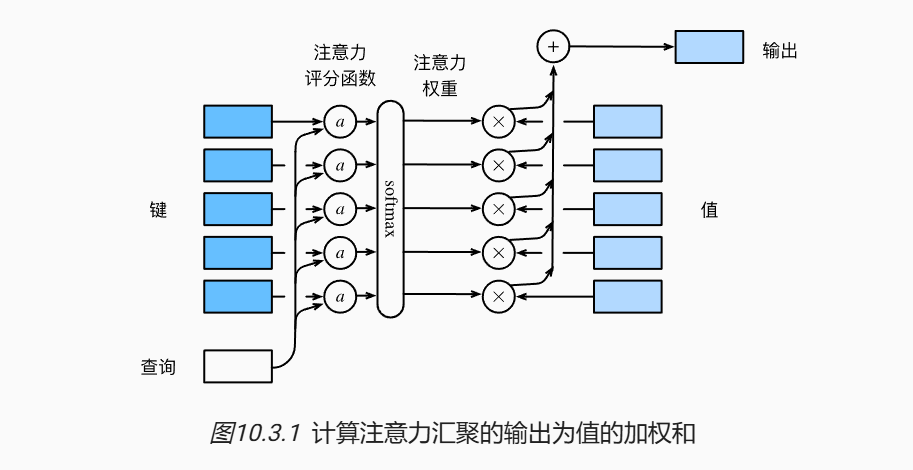
###### 选择不同的注意力评分机制会导致不同的注意力汇聚操作，现有的注意力评分函数是高斯核的指数部分，而接下来将介绍两个更加流行的评分函数，来实现更复杂的注意力机制。

In [12]:
import torch
import math
from torch import nn
from d2l import torch as d2l

##### ***掩蔽softmax操作***
###### softmax操作主要是输出一个概率分布作为注意力权重。然而某些情况下并非所有的值都应该被纳入到注意力汇聚中，比如某些文本序列会被填充没有意义的特殊词元，对于这些词元我们不希望它们也参与进注意力汇聚。所以，我们可以指定一个有效序列长度（也就是得到有效词元个数），以便计算softmax时过滤掉超过指定范围的位置。

In [13]:
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X:3D张量，valid_lens:1D或2D张量
    if valid_lens is None: # 如果没有指定有效序列长度，则直接返回softmax输出
        return nn.functional.softmax(X, dim=-1) #dim=-1表示在最后一个轴上计算softmax
    else:
        shape = X.shape
        if valid_lens.dim() == 1: # 判断valid_lens是否为1D张量
            valid_lens = torch.repeat_interleave(valid_lens, shape[1]) # 复制到每个样本的每个时间步也就是让一个批次的所有时间步的长度都符合valid_lens
        else:
            valid_lens = valid_lens.reshape(-1)
        # 最后一轴上被掩蔽的元素使用一个非常大的负值替换，从而其softmax输出为0
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value = -1e6) #将3D张量转换为2D张量，再进行掩蔽操作
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [14]:
masked_softmax(torch.randn(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.5738, 0.4262, 0.0000, 0.0000],
         [0.2834, 0.7166, 0.0000, 0.0000]],

        [[0.0948, 0.7160, 0.1892, 0.0000],
         [0.4282, 0.5305, 0.0413, 0.0000]]])

In [17]:
masked_softmax(torch.randn(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.6006, 0.2863, 0.1131, 0.0000]],

        [[0.0848, 0.9152, 0.0000, 0.0000],
         [0.4186, 0.1559, 0.1749, 0.2506]]])

##### ***加性注意力***
###### 一般来说，当查询和键是不同长度的矢量时，可以使用加性注意力作为评分函数。具体来说加性注意力的评分函数为：
$$\alpha(q, k) = w_v^Ttanh(W_qq + W_kk)\in\mathbb{R},$$
###### 其中可学习的参数是$W_q$、$W_k$和$w_v$。将查询和键连接起来后输入到一个MLP中，感知机包含一个隐藏层，其隐藏单元数是一个超参数h。通过tanh作为激活函数，并禁用偏置项。

In [18]:
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.w_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.w_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.w_q(queries), self.w_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size，查询的个数，1，num_hidden)
        # key的形状：(batch_size，1，“键－值”对的个数，num_hiddens)
        # 使用广播方式进行求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1) # (batch_size, 查询的个数, "键-值"对的个数, num_hiddens)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状：(batch_size，查询的个数，“键-值”对的个数)
        scores = self.w_v(features).squeeze(-1) #把最后一维变成1

        self.attention_weights = masked_softmax(scores, valid_lens)
        # values的形状：(batch_size，“键－值”对的个数，值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [22]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1) # 在0维度上重复2次，其他维度上不重复
valid_lens = torch.tensor([2, 6])
attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8, dropout=0.1)
attention.eval()
attention(queries, keys, values, valid_lens)


tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

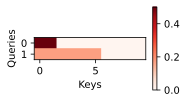

In [23]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)), xlabel='Keys', ylabel='Queries')

##### ***缩放点积注意力***
###### 使用点积可以得到计算效率更高的评分函数，但是点积操作要求查询和键具有相同的长度d，假设查询和键的所有元素都是独立的随机变量，并且都满足零均值和单位方差，那么两个向量的点积的均值为0，方差为d。为确保无论向量长度如何，点积的方差在不考虑向量长度的情况下依然是1，我们再将点积除以$\sqrt{d}$，则缩放点积注意力评分函数为：
$$\alpha(q, k) = q^Tk/\sqrt{d}$$
###### 在实践中，我们会使用小批量来提高效率，例如基于n个查询和m个键-值对计算注意力，其中查询和键的长度是d，值的长度为v。查询$Q\in \mathbb{R}^{n\times d}$，键$K\in \mathbb{R}^{m\times d}$，值$V\in \mathbb{R}^{m\times v}$，则缩放点积注意力评分函数为：
$$softmax(\frac{QK^T}{\sqrt{d}})V\in \mathbb{R}^{n\times v}$$

In [24]:
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries的形状：(batch_size，查询的个数，d)
    # keys的形状：(batch_size，“键－值”对的个数，d)
    # values的形状：(batch_size，“键－值”对的个数，值的维度)
    # valid_lens的形状:(batch_size，)或者(batch_size，查询的个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # 设置transpose_b=True为了交换keys的最后两个维度
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


In [25]:
queries = torch.normal(0, 1, (2, 1, 2))
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])

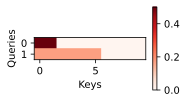

In [26]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')